## Imports

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from sequence_builder import (
    run_sequence_builder,
    get_sequence_lengths,
    get_sequence_as_list,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

In [2]:
!pip install pandas matplotlib seaborn

## Build Sequences

In [3]:
processed_path = "../data/processed/"

student_sequences = run_sequence_builder(processed_path)

print("Shape:", student_sequences.shape)
print("Columns:", student_sequences.columns.tolist())
print()
student_sequences.head(10)

Shape: (20788, 3)
Columns: ['id_student', 'sequence', 'performance_label']



,id_student,sequence,performance_label
0,6516,"StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,Naviga...",Pass
1,11391,"StudyMaterial,StudyMaterial,Discussion,StudyMaterial,Discussion,StudyMateria...",Pass
2,23629,"Navigation,Discussion,Discussion,Discussion,Navigation,Discussion,Navigation...",Fail
3,23698,"Navigation,Navigation,StudyMaterial,StudyMaterial,StudyMaterial,External,Nav...",Pass
4,23798,"StudyMaterial,StudyMaterial,Navigation,Discussion,Navigation,External,StudyM...",Pass
5,24186,"StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,Naviga...",Pass
6,24213,"StudyMaterial,Navigation,Navigation,Navigation,Discussion,Discussion,StudyMa...",Pass
7,24391,"StudyMaterial,StudyMaterial,StudyMaterial,Navigation,Navigation,StudyMateria...",Pass
8,24734,"StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,Navigation,StudyMate...",Pass
9,25107,"Navigation,Discussion,Discussion,Navigation,Discussion,External,Discussion,S...",Pass


## Performance Label Distribution

In [4]:
label_counts = student_sequences["performance_label"].value_counts()
print("Performance label counts:")
print(label_counts)
print()
pct = (label_counts / len(student_sequences) * 100).round(1)
print("Percentages:")
print(pct)

Performance label counts:
performance_label
Pass    14323
Fail     6465
Name: count, dtype: int64

Percentages:
performance_label
Pass    68.9
Fail    31.1
Name: count, dtype: float64


## Sequence Length Analysis

In [5]:
student_sequences["seq_length"] = get_sequence_lengths(student_sequences)

print("Sequence length statistics:")
print(student_sequences["seq_length"].describe().round(1))

Sequence length statistics:
count    20788.0
mean       537.6
std        651.7
min          1.0
25%        161.0
50%        347.0
75%        690.0
max      19167.0
Name: seq_length, dtype: float64


### Sequence Length by Performance Group

In [6]:
print("Mean sequence length by performance:")
print(
    student_sequences.groupby("performance_label")["seq_length"]
    .mean()
    .round(1)
)
print()
print("Median sequence length by performance:")
print(
    student_sequences.groupby("performance_label")["seq_length"]
    .median()
    .round(1)
)

Mean sequence length by performance:
performance_label
Fail    272.7
Pass    657.2
Name: seq_length, dtype: float64

Median sequence length by performance:
performance_label
Fail    144.0
Pass    462.0
Name: seq_length, dtype: float64


### Plot 1 — Sequence Length Distribution

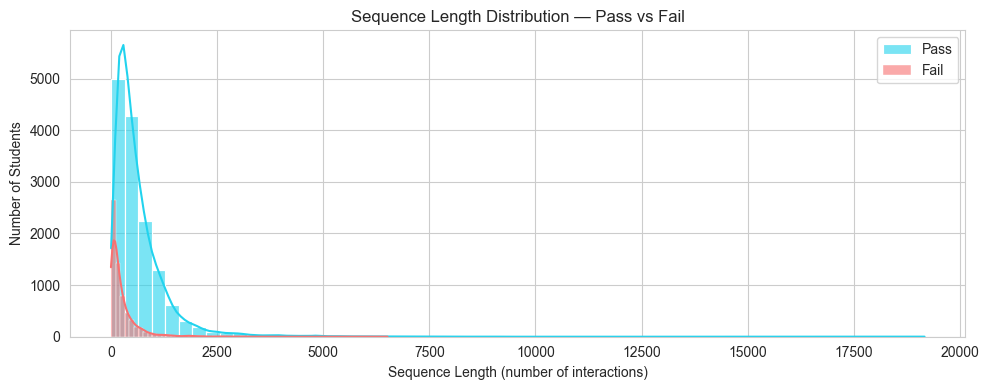

Saved to results/figures/sequence_length_distribution.png


In [7]:
plt.figure(figsize=(10, 4))

for label, color in [("Pass", "#22d3ee"), ("Fail", "#f87171")]:
    subset = student_sequences[student_sequences["performance_label"] == label]
    sns.histplot(
        subset["seq_length"],
        bins=60,
        color=color,
        label=label,
        alpha=0.6,
        kde=True,
    )

plt.title("Sequence Length Distribution — Pass vs Fail")
plt.xlabel("Sequence Length (number of interactions)")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/sequence_length_distribution.png", dpi=150)
plt.show()
print("Saved to results/figures/sequence_length_distribution.png")

### Plot 2 — Sequence Length Boxplot (Pass vs Fail)

C:\Users\Samridhaa\AppData\Local\Temp\ipykernel_49256\1438174326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


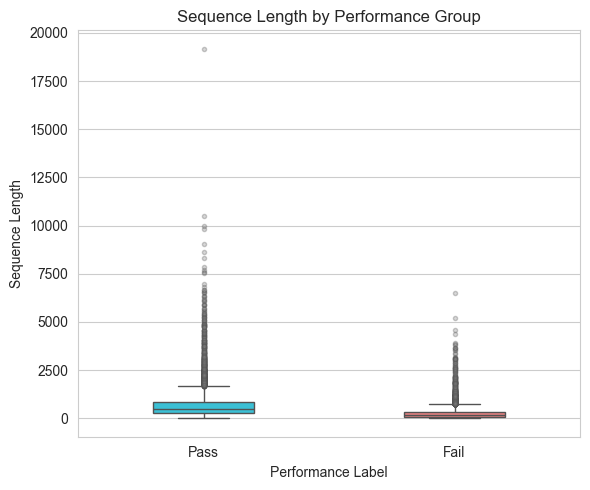

Saved to results/figures/sequence_length_boxplot.png


In [8]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=student_sequences,
    x="performance_label",
    y="seq_length",
    palette={"Pass": "#22d3ee", "Fail": "#f87171"},
    width=0.4,
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.3),
)

plt.title("Sequence Length by Performance Group")
plt.xlabel("Performance Label")
plt.ylabel("Sequence Length")
plt.tight_layout()
plt.savefig("../results/figures/sequence_length_boxplot.png", dpi=150)
plt.show()
print("Saved to results/figures/sequence_length_boxplot.png")

## Sample Sequences

In [9]:

print("5 PASS student sequences")

pass_samples = student_sequences[student_sequences["performance_label"] == "Pass"].head(5)
for _, row in pass_samples.iterrows():
    seq_list = get_sequence_as_list(row["sequence"])
    print(f"Student {row['id_student']} (len={len(seq_list)}):")
    print(f"  {seq_list[:15]}{'...' if len(seq_list) > 15 else ''}")
    print()


print("5 FAIL student sequences")

fail_samples = student_sequences[student_sequences["performance_label"] == "Fail"].head(5)
for _, row in fail_samples.iterrows():
    seq_list = get_sequence_as_list(row["sequence"])
    print(f"Student {row['id_student']} (len={len(seq_list)}):")
    print(f"  {seq_list[:15]}{'...' if len(seq_list) > 15 else ''}")
    print()

5 PASS student sequences
Student 6516 (len=662):
  ['StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'Discussion', 'Discussion', 'StudyMaterial', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'Discussion', 'StudyMaterial']...

Student 11391 (len=196):
  ['StudyMaterial', 'StudyMaterial', 'Discussion', 'StudyMaterial', 'Discussion', 'StudyMaterial', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'Discussion', 'StudyMaterial', 'Discussion', 'StudyMaterial']...

Student 23698 (len=305):
  ['Navigation', 'Navigation', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'External', 'Navigation', 'StudyMaterial', 'Navigation', 'Quiz', 'Quiz', 'Quiz', 'StudyMaterial', 'StudyMaterial', 'Quiz']...

Student 23798 (len=306):
  ['StudyMaterial', 'StudyMaterial', 'Navigation', 'Discussion', 'Navigation', 'External', 'StudyMaterial', 'Discussion', 'External', 'Discussion', 'StudyMaterial', 'Discuss

## Pre-course Engagement Check

Students who engaged **before** the course starts (negative dates) appear first in the sequence. 

In [10]:

logs = pd.read_csv("../data/processed/clean_logs.csv")

# Students with at least one interaction before course start (date < 0)
pre_course = logs[logs["date"] < 0]
pre_course_students = pre_course["id_student"].nunique()
total_students = logs["id_student"].nunique()

print(f"Students with pre-course activity : {pre_course_students:,}")
print(f"Total students                     : {total_students:,}")
print(f"Percentage with pre-course activity: {pre_course_students/total_students*100:.1f}%")
print()

# Pre-course engagement by performance
pre_course_merged = pre_course.groupby("id_student")["final_result"].first().reset_index()
print("Pre-course students by performance:")
print(pre_course_merged["final_result"].value_counts())

Students with pre-course activity : 17,170
Total students                     : 20,788
Percentage with pre-course activity: 82.6%

Pre-course students by performance:
final_result
Pass    12309
Fail     4861
Name: count, dtype: int64


## Verify: Reload and Check Sequence

In [11]:

sample_student = student_sequences.iloc[0]["id_student"]

student_logs = logs[logs["id_student"] == sample_student].sort_values("date")

print(f"Student {sample_student} — raw log (first 10 rows):")
print(student_logs[["date", "activity_type", "activity_category"]].head(10).to_string(index=False))
print()

built_seq = get_sequence_as_list(
    student_sequences[student_sequences["id_student"] == sample_student]["sequence"].values[0]
)
print(f"Built sequence (first 10): {built_seq[:10]}")

Student 6516 — raw log (first 10 rows):
 date activity_type activity_category
  -23     oucontent     StudyMaterial
  -23     oucontent     StudyMaterial
  -23     oucontent     StudyMaterial
  -23     oucontent     StudyMaterial
  -23      homepage        Navigation
  -23       subpage     StudyMaterial
  -22     oucontent     StudyMaterial
  -22      homepage        Navigation
  -22     oucontent     StudyMaterial
  -22       forumng        Discussion

Built sequence (first 10): ['StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'Discussion', 'Discussion', 'StudyMaterial']


## Save student_sequences.csv

In [12]:

save_df = student_sequences[["id_student", "sequence", "performance_label"]]

output_path = "../data/processed/student_sequences.csv"
save_df.to_csv(output_path, index=False)

print(f"Saved {len(save_df):,} students to {output_path}")
print(f"Columns: {save_df.columns.tolist()}")
print()
print("Preview:")
save_df.head()

Saved 20,788 students to ../data/processed/student_sequences.csv
Columns: ['id_student', 'sequence', 'performance_label']

Preview:


,id_student,sequence,performance_label
0,6516,"StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,Naviga...",Pass
1,11391,"StudyMaterial,StudyMaterial,Discussion,StudyMaterial,Discussion,StudyMateria...",Pass
2,23629,"Navigation,Discussion,Discussion,Discussion,Navigation,Discussion,Navigation...",Fail
3,23698,"Navigation,Navigation,StudyMaterial,StudyMaterial,StudyMaterial,External,Nav...",Pass
4,23798,"StudyMaterial,StudyMaterial,Navigation,Discussion,Navigation,External,StudyM...",Pass


In [13]:
# Cell 1
from sequence_builder import apply_performance_grouping

student_sequences = apply_performance_grouping(student_sequences)
print("Columns:", student_sequences.columns.tolist())
student_sequences.head(3)

Columns: ['id_student', 'sequence', 'performance_label', 'seq_length', 'performance_group']


,id_student,sequence,performance_label,seq_length,performance_group
0,6516,"StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,StudyMaterial,Naviga...",Pass,662,High
1,11391,"StudyMaterial,StudyMaterial,Discussion,StudyMaterial,Discussion,StudyMateria...",Pass,196,High
2,23629,"Navigation,Discussion,Discussion,Discussion,Navigation,Discussion,Navigation...",Fail,59,Low


In [14]:
# Cell 2
group_counts = student_sequences["performance_group"].value_counts()
print(group_counts)

performance_group
High    14323
Low      6465
Name: count, dtype: int64


In [15]:
# Cell 3 — Save
output_path = "../data/processed/student_sequences.csv"
student_sequences[["id_student", "sequence", "performance_label", "performance_group"]].to_csv(
    output_path, index=False
)
print(f"Saved {len(student_sequences):,} students to {output_path}")
print(f"Columns: {student_sequences.columns.tolist()}")

Saved 20,788 students to ../data/processed/student_sequences.csv
Columns: ['id_student', 'sequence', 'performance_label', 'seq_length', 'performance_group']
